In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm 
import os
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader
import torch
from torch.utils.data import Dataset, DataLoader
from typing import List, Optional
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error

In [7]:
def load_data(path="C:/Project_Mash/apartment_18_10s.csv"):
    df = pd.read_csv(path, parse_dates=['timestamp'], index_col='timestamp')
    return df


In [8]:
def add_time_features(df):

    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    df.index = df.index.tz_convert("Asia/Tehran")

    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek  

    # Thursday (3) and Friday (4)
    df['is_weekend'] = df['day_of_week'].isin([3, 4]).astype(int)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    return df

In [9]:
def add_heating_duration(df, time_threshold='5min'):
    df = df.copy()
    
    df['time_diff'] = df.index.to_series().diff().dt.total_seconds()
    df['is_gap'] = df['time_diff'] > pd.Timedelta(time_threshold).total_seconds()
    
    # Reset duration at gaps
    duration = 0
    durations = []
    prev_status = None
    
    for i, (status, is_gap) in enumerate(zip(df['heating_status'], df['is_gap'])):
        if i == 0 or is_gap:
            duration = 0
        elif status == prev_status:
            duration += df['time_diff'].iloc[i]
        else:
            duration = 0
            
        durations.append(duration)
        prev_status = status
    
    df['heating_duration_sec'] = durations
    df['heating_duration_min'] = df['heating_duration_sec'] / 60
    return df.drop(columns=['time_diff', 'is_gap'])

In [10]:
class TimeAwareSeriesDataset(Dataset):
    def __init__(self, df, cont_features, bin_features, target_col='avg_indoor_temperature',
                 history_hours=3, pred_horizon_hours=2, max_gap_minutes=15, scaler=None):
        
        if not isinstance(df.index, pd.DatetimeIndex):
            raise ValueError("DataFrame must have a DatetimeIndex")
            
        df = df.copy()
        self.cont_features = cont_features
        self.bin_features = bin_features
        self.features = cont_features + bin_features
        self.target_col = target_col
        self.max_gap_minutes = max_gap_minutes

        # Normalize
        self.scaler = scaler or MinMaxScaler()
        if scaler is None:
            df[cont_features] = self.scaler.fit_transform(df[cont_features])
        else:
            df[cont_features] = self.scaler.transform(df[cont_features])

        # Add shifted target column
        self.df = df
        self.df['target_temp'] = self.df[target_col].shift(-pred_horizon_hours)
        self.df.dropna(subset=['target_temp'], inplace=True)

        # Time gaps
        deltas = self.df.index.to_series().diff().dt.total_seconds().div(60).fillna(0)
        self.deltas = deltas.values
        # In TimeAwareSeriesDataset.__init__
        #self.deltas = np.diff(self.df.index.values) / np.timedelta64(1, 'm')  # Assuming deltas is in minutes

        # Compute intervals
        self.median_interval = np.median(self.deltas[1:])  # skip first NaN
        self.history_length = int(history_hours * 60 / self.median_interval)
        self.pred_horizon = int(pred_horizon_hours * 60 / self.median_interval)
        self.total_window = self.history_length + self.pred_horizon

        # Find valid indices
        self.valid_idx = self._compute_valid_indices()

    def _compute_valid_indices(self):
        valid_indices = []
        for i in range(len(self.df) - self.total_window):
            history_ok = np.all(self.deltas[i+1:i+self.history_length] <= self.max_gap_minutes)
            pred_ok = np.all(self.deltas[i+self.history_length:i+self.total_window] <= self.max_gap_minutes)
            if history_ok and pred_ok:
                valid_indices.append(i)
        return valid_indices

    def __len__(self):
        return len(self.valid_idx)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise StopIteration  # Prevents infinite loops
        i = self.valid_idx[idx]
        window = self.df.iloc[i:i + self.history_length]
        x = torch.tensor(window[self.features].values, dtype=torch.float32)
        y = torch.tensor([self.df.iloc[i + self.history_length - 1]['target_temp']], dtype=torch.float32)
        return x, y

In [11]:
# checking for duplication
df = pd.read_csv("C:/Project_Mash/apartment_18_10s.csv", parse_dates=["timestamp"])
print(df["timestamp"].duplicated().sum())

0


In [13]:
class TimeSeriesMLP(nn.Module):
    def __init__(self, input_features, seq_length):
        super().__init__()
        self.temporal_compressor = nn.Sequential(
            nn.Linear(seq_length, 64),
            nn.ReLU()
        )
        self.net = nn.Sequential(
            nn.Linear(64 * input_features, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (batch, features, time)
        x = self.temporal_compressor(x)  # Compress time
        x = x.reshape(x.size(0), -1)  # Flatten
        return self.net(x)

# 3. Load and preprocess your data
def load_and_preprocess_data():
    df = load_data()
    df = df.loc['2025-01-31':'2025-02-15'].copy()
    df = add_time_features(df)
    df = add_heating_duration(df)
    split_point = int(0.8 * len(df))
    return df.iloc[:split_point].copy(), df.iloc[split_point:].copy()

# 4. Create datasets
df_train, df_test = load_and_preprocess_data()

binary_features = ['heating_status', 'is_weekend']
continuous_features = [
    'avg_indoor_temperature', 'avg_indoor_humidity',
    'avg_piping_temperature', 'solar_radiation', 
    'outdoor_temp', 'hour_sin', 'hour_cos', 'heating_duration_min'
]

# Option 1: Use modified dataset class (recommended)
train_dataset = TimeAwareSeriesDataset(
    df_train,  # Now passing DataFrame directly
    continuous_features,
    binary_features,
    history_hours=3,
    pred_horizon_hours=2,
    max_gap_minutes=15
)

test_dataset = TimeAwareSeriesDataset(
    df_test,
    continuous_features,
    binary_features,
    scaler=train_dataset.scaler,
    history_hours=3,
    pred_horizon_hours=2,
    max_gap_minutes=15
)


print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

# 5. NOW initialize model with the datasets
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TimeSeriesMLP(
    input_features=len(train_dataset.features),
    seq_length=train_dataset.history_length
).to(device)

USE_AMP = (device.type == 'cuda')

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    
    # Use automatic mixed precision for faster training
    scaler = torch.amp.GradScaler() if USE_AMP else None
    
    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)  # Faster zero_grad
        
        with torch.amp.autocast(device_type=device.type):
            outputs = model(X)
            loss = criterion(outputs, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item() * X.size(0)
    
    return total_loss / len(loader.dataset)

# Optimized evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            outputs = model(X)
            loss = criterion(outputs, y)
            total_loss += loss.item() * X.size(0)
            
            # More efficient tensor handling
            all_preds.append(outputs.detach().cpu())
            all_true.append(y.detach().cpu())
    
    # Single concatenation at end
    all_preds = torch.cat(all_preds).numpy().flatten()
    all_true = torch.cat(all_true).numpy().flatten()
    
    mae = mean_absolute_error(all_true, all_preds)
    return total_loss / len(loader.dataset), mae

# Initialize model 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TimeSeriesMLP(
    input_features=len(train_dataset.features),
    seq_length=train_dataset.history_length
).to(device)
print(f"Model architecture:\n{model}")

# Training setup with optimized data loaders
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,  # turn off
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False
)

# Training loop
best_val_loss = float('inf')
patience = 5
no_improve = 0
train_losses = []
val_losses = []
val_maes = []

Train size: 95202, Test size: 23521
Model architecture:
TimeSeriesMLP(
  (temporal_compressor): Sequential(
    (0): Linear(in_features=1080, out_features=64, bias=True)
    (1): ReLU()
  )
  (net): Sequential(
    (0): Linear(in_features=640, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# 1) Prepare
os.makedirs('saved_models', exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = (device.type == 'cuda')
best_val_loss = float('inf')
no_improve = 0
patience = 5

train_losses, val_losses, val_maes = [], [], []

# 2) Main training loop
for epoch in range(1, 21):
    # ---- TRAIN ----
    model.train()
    scaler = torch.amp.GradScaler() if USE_AMP else None
    total_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.amp.autocast(device_type=device.type):
                outputs = model(X)
                loss = criterion(outputs, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * X.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # ---- VALIDATE ----
    val_loss, val_mae = evaluate(model, test_loader, criterion, device)
    val_losses.append(val_loss)
    val_maes.append(val_mae)

    print(f"Epoch {epoch:>2} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f}")

    # ---- EARLY STOP & SAVE ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'saved_models/best_model.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
else:
    # this else is aligned with the for-loop
    print("Training completed without early stopping.")

# At the end, just to be safe, load and save the best model again
model.load_state_dict(torch.load('saved_models/best_model.pth'))
torch.save(model.state_dict(), 'saved_models/final_best_model.pth')


Epoch  1 | Train Loss: 0.0078 | Val Loss: 0.0035 | Val MAE: 0.0453
Epoch  2 | Train Loss: 0.0004 | Val Loss: 0.0025 | Val MAE: 0.0379
Epoch  3 | Train Loss: 0.0002 | Val Loss: 0.0026 | Val MAE: 0.0375
Epoch  4 | Train Loss: 0.0002 | Val Loss: 0.0024 | Val MAE: 0.0355
Epoch  5 | Train Loss: 0.0001 | Val Loss: 0.0020 | Val MAE: 0.0332
Epoch  6 | Train Loss: 0.0001 | Val Loss: 0.0019 | Val MAE: 0.0317
Epoch  7 | Train Loss: 0.0001 | Val Loss: 0.0016 | Val MAE: 0.0290
Epoch  8 | Train Loss: 0.0001 | Val Loss: 0.0017 | Val MAE: 0.0297
Epoch  9 | Train Loss: 0.0001 | Val Loss: 0.0017 | Val MAE: 0.0293
Epoch 10 | Train Loss: 0.0001 | Val Loss: 0.0015 | Val MAE: 0.0272
Epoch 11 | Train Loss: 0.0001 | Val Loss: 0.0018 | Val MAE: 0.0299
Epoch 12 | Train Loss: 0.0001 | Val Loss: 0.0015 | Val MAE: 0.0278
Epoch 13 | Train Loss: 0.0001 | Val Loss: 0.0014 | Val MAE: 0.0262
Epoch 14 | Train Loss: 0.0001 | Val Loss: 0.0014 | Val MAE: 0.0270
Epoch 15 | Train Loss: 0.0001 | Val Loss: 0.0013 | Val MAE: 0.

C:\Users\navid\AppData\Local\Temp\ipykernel_23904\2770721219.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('saved_models/best_model.p


Unseen‐window Performance (2025-02-27→02-03):
  Loss: 0.0005 | MAE: 0.0170


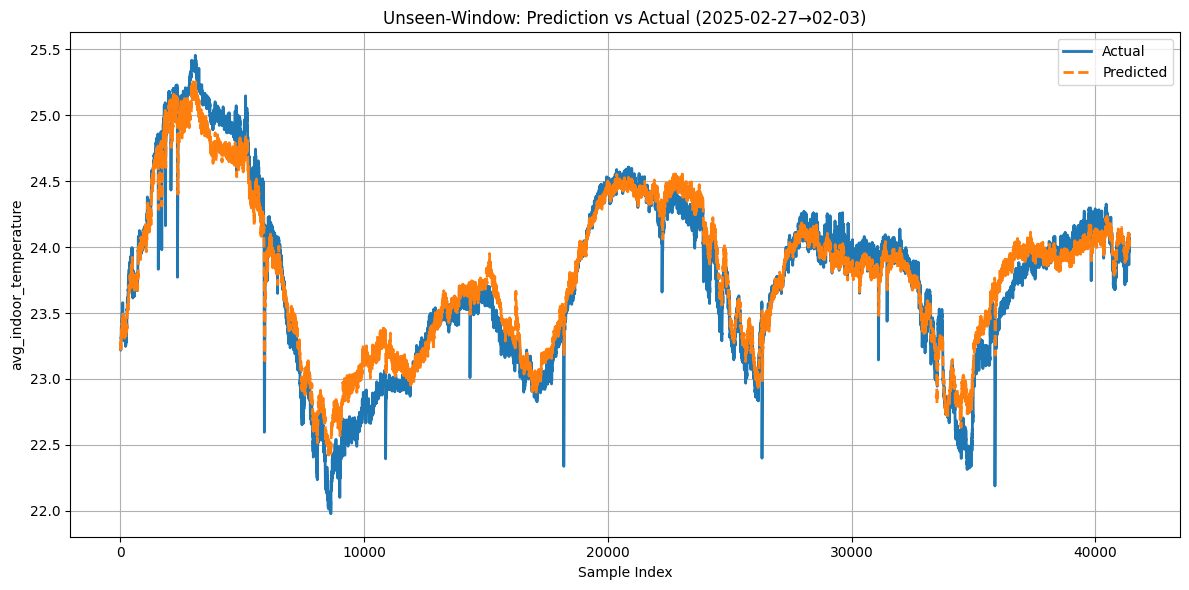

In [9]:
# 1) New loader for the “future” window
def load_evaluation_data():
    df = load_data()
    # select Feb 1–5, 2025
    df = df.loc['2025-02-27':'2025-03-03'].copy()
    df = add_time_features(df)
    df = add_heating_duration(df)
    return df

# 2) Build eval dataset + loader
df_eval = load_evaluation_data()
eval_dataset = TimeAwareSeriesDataset(
    df_eval,
    cont_features=continuous_features,
    bin_features=binary_features,
    scaler=train_dataset.scaler,           # reuse train-time scaler
    history_hours=3,
    pred_horizon_hours=2,
    max_gap_minutes=15
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,                         # safe in notebook
    pin_memory=torch.cuda.is_available()
)

# 3) Load best model & evaluate
model.load_state_dict(torch.load('saved_models/best_model.pth', map_location=device))
eval_loss, eval_mae = evaluate(model, eval_loader, criterion, device)
print(f"\nUnseen‐window Performance (2025-02-27→02-03):")
print(f"  Loss: {eval_loss:.4f} | MAE: {eval_mae:.4f}")

# 4) Collect predictions + plot
def collect_predictions(model, dataset, device, scaler=None):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for i in range(len(dataset)):
            X, y = dataset[i]
            pred = model(X.unsqueeze(0).to(device)).cpu().item()
            target = y.item()

            # inverse‐scale to original units if needed
            if scaler is not None and dataset.target_col in dataset.cont_features:
                dummy = np.zeros(len(dataset.cont_features))
                idx = dataset.cont_features.index(dataset.target_col)

                dummy[idx] = pred
                pred = scaler.inverse_transform([dummy])[0][idx]
                dummy[idx] = target
                target = scaler.inverse_transform([dummy])[0][idx]

            preds.append(pred)
            targets.append(target)
    return preds, targets

preds, targets = collect_predictions(model, eval_dataset, device, scaler=train_dataset.scaler)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(targets, label='Actual', linewidth=2)
plt.plot(preds,   label='Predicted', linestyle='--', linewidth=2)
plt.title("Unseen‐Window: Prediction vs Actual (2025-02-27→02-03)")
plt.xlabel("Sample Index")
plt.ylabel(eval_dataset.target_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


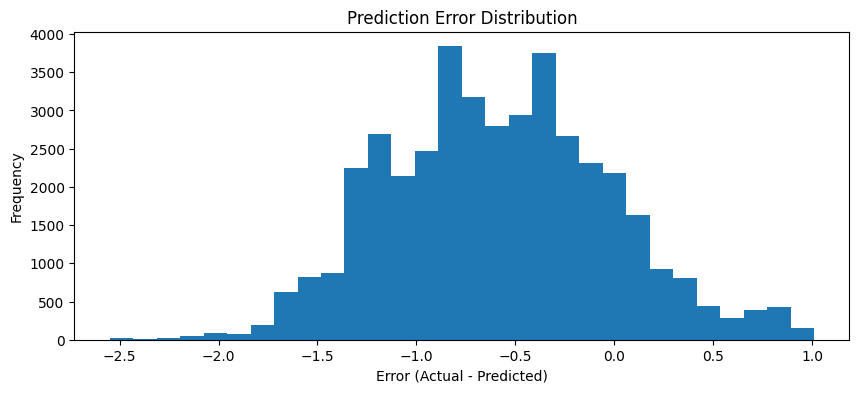

In [65]:
errors = np.array(targets) - np.array(preds)
plt.figure(figsize=(10,4))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()